<a href="https://colab.research.google.com/github/soraya-da/mobilidad-en-Latam/blob/main/urban_mobility_economic_productivity_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Movilidad urbana y productividad económica en América Latina

## Descripción del proyecto

Este proyecto analiza la relación entre la movilidad urbana y la productividad económica en ciudades de América Latina.

El análisis integra dos fuentes de datos: una relacionada con las condiciones de tráfico urbano y otra con indicadores económicos de las ciudades. El objetivo es evaluar si existe una relación entre el PIB per cápita y los niveles de congestión, así como identificar patrones relevantes para la planificación urbana y la toma de decisiones.

## Objetivos

- Limpiar y estandarizar dos conjuntos de datos.
- Validar tipos de datos y valores faltantes.
- Integrar información de movilidad y economía.
- Filtrar el análisis al periodo seleccionado.
- Calcular indicadores agregados por ciudad.
- Realizar un análisis exploratorio de datos.
- Visualizar la relación entre congestión y productividad económica.
- Presentar conclusiones y recomendaciones basadas en los resultados.

## Herramientas utilizadas

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

## 1. Configuración del entorno

In [ ]:
# Importación de librerías para manipulación y visualización de datos
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Carga de los datos



In [ ]:
# Carga de los conjuntos de datos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
eco.head()# mostrar las primeras 5 filas de eco

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


## 3. Explorar, limpiar y preparar los datos

In [ ]:
traffic.info()# Examinar la estructura de traffic

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTC` son de tipo string/object. Es necesario convertir a datetime.
- Las columnas de 'JamsDelay' 'TrafficIndexLive' JamsLengthInKms' y 'Jamscount' son float, es decir numero.

In [ ]:

eco.info()# Examinar la estructura de eco

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


<div style="background-color: lightblue; padding: 10px;">
En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, '`Population (M) %`y 'PM2.5(μ/m³) son tipo string/object, y por su caracteristicas deberian ser float64, lo cual indica necesidad de conversion.
- La columna `Year`es int64 lo cual esta bien y no habria necesidad de convertirla.
    Tambien se ven nombres de columnas repetidas en ambos datasets como city y country.
</div>

En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, '`Population (M) %`son de texto.
- La columna `Year`es numerica.

In [ ]:
# Estandarizar los nombres de las columnas de traffic
traffic = traffic.rename(columns={'City': 'city', 'Country': 'country',
                                  'UpdateTimeUTC': 'update_time_utc',
                                  'UpdateTimeUTCWeekAgo': 'updated_time_utc_week_ago',
                                  'TrafficIndexWeekAgo': 'traffic_index_week_ago',
                                  'JamsDelay': 'jams_delay',
                                  'TrafficIndexLive': 'traffic_index_live',
                                 'JamsLengthInKms': 'jams_length_kms',
                                 'JamsCount': 'jams_count',
                                 'MinsDelay': 'mins_delay',
                                 'TravelTimeLivePer10KmsMins': 'travel_time_live_per_10kms_mins' ,
                                  'TravelTimeHistoricPer10KmsMins' : 'travel_time_hist_per_10kms_mins'}
                                 )
# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'traffic_index_week_ago', 'updated_time_utc_week_ago',
       'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins',
       'mins_delay'],
      dtype='object')

In [ ]:
# Estandarizar los nombres de las columnas de eco
eco = eco.rename(columns={'PM2.5 (μg/m³)': 'pm_2.5_ug/m3', 'Year' : 'year', 'City' : 'city','Country': 'country', 'City GDP/capita': 'city_gdp_capita' , 'Unemployment %': 'unemployment_pct', 'Population (M)': 'population_m'})#tu código aquí

# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm_2.5_ug/m3', 'population_m'],
      dtype='object')

In [ ]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors="coerce", utc=True)
traffic['updated_time_utc_week_ago'] = pd.to_datetime(traffic['updated_time_utc_week_ago'], errors="coerce", utc=True)#tu código aquí

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                           Non-Null Count    Dtype              
---  ------                           --------------    -----              
 0   country                          1004464 non-null  object             
 1   city                             1004464 non-null  object             
 2   update_time_utc                  1004464 non-null  datetime64[ns, UTC]
 3   jams_delay                       1004464 non-null  float64            
 4   traffic_index_live               1004464 non-null  float64            
 5   jams_length_kms                  1004464 non-null  float64            
 6   jams_count                       1004464 non-null  float64            
 7   traffic_index_week_ago           1004464 non-null  float64            
 8   updated_time_utc_week_ago        1004464 non-null  datetime64[ns, UTC]
 9   travel_time_live_per_10kms_mins  1004464 non-n

In [ ]:
# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_capita'] = (
    eco['city_gdp_capita']
    .astype(str)
    .str.strip()
    .str.replace('.', '', regex=False)   # quita separador de miles
    .str.replace(',', '.', regex=False)  # cambia decimal
    .astype(float)
)

eco['unemployment_pct'] = (
    eco['unemployment_pct']
    .astype(str)
    .str.strip()
    .str.replace(',' , '.')
    .str.replace('%' , '')
    .astype(float)
)

eco['population_m'] = (
    eco['population_m']
    .astype(str)
    .str.strip()
    .str.replace(',' , '.')
    .astype(float)
)
eco['pm_2.5_ug/m3'] = (
    eco['pm_2.5_ug/m3']
    .astype(str)
    .str.strip()
    .str.replace(',' , '.')
    .astype(float)
)
# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco['population_m'] * 1_000_000

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm_2.5_ug/m3      30 non-null     float64
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(5), int64(1), object(2)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm_2.5_ug/m3,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,15.2,15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,29.5,22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,19.1,13.6,13600000.0


In [ ]:
# Extraer el año REAL de las fechas
traffic['year'] = traffic['update_time_utc'].dt.year

# Filtrar solo las filas del año 2024
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year']== 2024].copy()

## 4. Extraer año y filtros

In [ ]:
# Filtra los registros del año 2024

traffic_2024 = traffic[traffic['year'] == 2024]


# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,updated_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30+00:00,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001000+00:00,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30+00:00,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30+00:00,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30+00:00,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30+00:00,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001000+00:00,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001000+00:00,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00+00:00,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00+00:00,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm_2.5_ug/m3,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,14.5,15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,28.0,22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,18.4,13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,12.8,4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,15.2,3.9,3900000.0


## 5. Analizar y resumir datos de movilidad

In [ ]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = (
    traffic_2024.groupby(['city', 'country', 'year'])
    .agg({
        'jams_delay': 'mean',
        'traffic_index_live': 'mean',
        'jams_length_kms': 'mean',
        'jams_count': 'mean',
        'mins_delay': 'mean',
        'travel_time_live_per_10kms_mins': 'mean',
        'travel_time_hist_per_10kms_mins': 'mean'
    })
    .reset_index()  # mantiene city, country y year como columnas
)

# Mostrar primeras filas
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


In [ ]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False) # la ciudad con el mayor tiempo promedio es Mexico en 2024

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es Mexico_city.

In [ ]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']
right_cols = ['city','year','city_gdp_capita','unemployment_pct','population']

traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city', 'year'], how='inner')

# Mostrar resultado
print("Filas en merged:", len(merged))
merged.head()

Filas en merged: 15


,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,city_gdp_capita,unemployment_pct,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,3700000.0


## 6. Visualización y análisis de relaciones

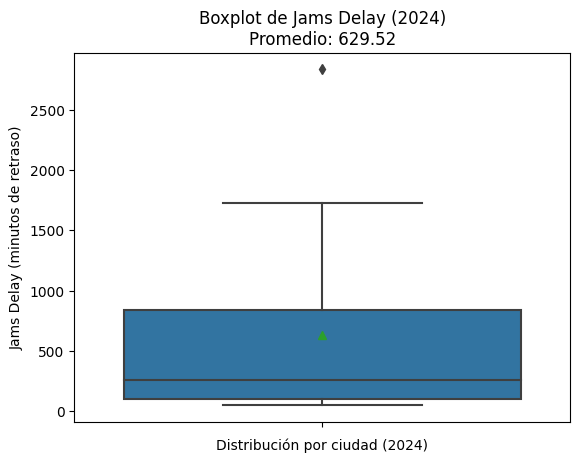

In [ ]:
mean_value = merged['jams_delay'].mean()

sns.boxplot(data=merged, y='jams_delay', showmeans=True)

plt.title(f'Boxplot de Jams Delay (2024)\nPromedio: {mean_value:.2f}')
plt.ylabel('Jams Delay (minutos de retraso)')  # ← etiqueta eje Y
plt.xlabel('Distribución por ciudad (2024)')   # ← etiqueta eje X
plt.show()


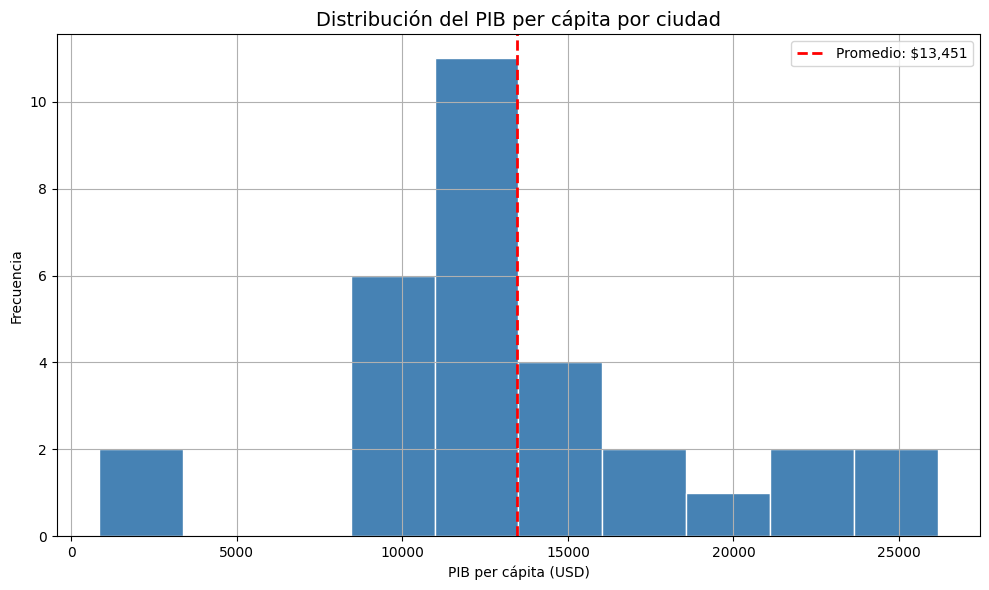

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Histograma con más detalle
eco['city_gdp_capita'].hist(bins=10, ax=ax, color='steelblue', edgecolor='white')

# Línea del promedio
mean_val = eco['city_gdp_capita'].mean()
ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Promedio: ${mean_val:,.0f}')

# Etiquetas
ax.set_title('Distribución del PIB per cápita por ciudad', fontsize=14)
ax.set_xlabel('PIB per cápita (USD)')
ax.set_ylabel('Frecuencia')
ax.legend()

plt.tight_layout()
plt.show()

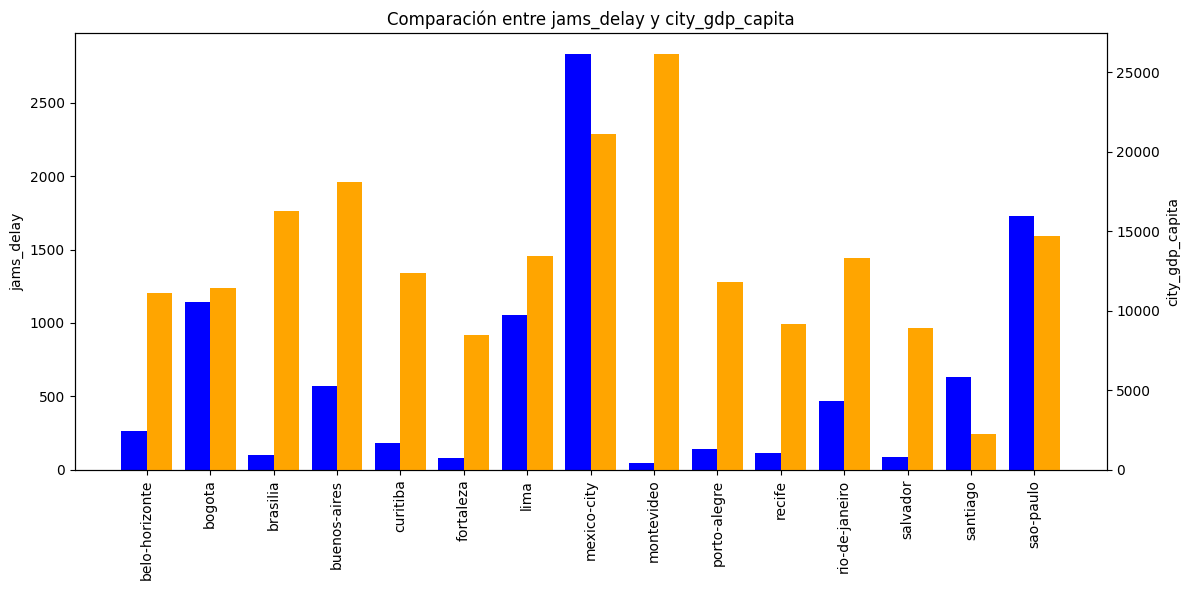

In [ ]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
# Primero generamos una lista que sea un rango de datos desde 0 hasta el tamaño del número de ciudades consideradas
x = np.arange(len(merged['city']))


#Después inicializamos el frame donde vamos a graficar, colocamos un tamaño grande con figsize:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje 1 (izquierdo)
# Aqui definimos con la gráfica bar el tema de bar(cuánto se desplaza cada barra graficada, mis valores de barra de acuerdo a jams_delay, el ancho de la barra, el color)
ax1.bar(x - 0.2, merged['jams_delay'], 0.4, color='blue')
ax1.set_ylabel("jams_delay")

# Eje 2 (derecho)
# Aqui hacemos la otra definición de eje, pero ahora colocándo las barras en la segunda mitad de cada espacio. Básicamente se mueven las barras un poquito (-0.2 y +0.2) para que no se encimen.
ax2 = ax1.twinx() # Es el que nos ayuda a generar el segundo eje.
ax2.bar(x + 0.2, merged['city_gdp_capita'], 0.4, color='orange')
ax2.set_ylabel("city_gdp_capita")

ax1.set_xticks(x)
ax1.set_xticklabels(merged['city'], rotation=90) # los nombres del eje x

plt.title("Comparación entre jams_delay y city_gdp_capita")
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; padding: 10px;">
Mirando los tres gráficos en conjunto, la evidencia demuestra que no existe una relación clara y directa entre PIB per cápita y congestión de tráfico. Casos como Montevideo (PIB ~$27,000, uno de los más altos, pero congestión ~2,750 minutos, la más alta) y Mexico City (PIB ~$21,000 con congestión ~2,650 minutos) contradicen completamente la hipótesis de que mayor PIB implica menor congestión; mientras que Brasilia (PIB ~$18,000, bajo, pero congestión apenas ~120 minutos) muestra que es posible tener baja congestión sin alto PIB. Por lo tanto, el PIB per cápita no es un buen predictor de congestión urbana, y los análisis futuros deberían enfocarse en indicadores de infraestructura vial y transporte público en lugar de variables económicas generales.
</div>

## 7. Exportar y documentar resultados

In [ ]:


# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)



In [ ]:
import os
import pandas as pd

# 1. EXPORTAR EL DATASET
file_path = "ladb_mobility_economy_2024_clean.csv"  # Cambia el nombre según tu proyecto

# Exportar
traffic_city_year_2024.to_csv(file_path, index=False)
print("✅ Archivo exportado exitosamente")

# 2. VERIFICACIÓN DEL TAMAÑO DEL ARCHIVO
file_size = os.path.getsize(file_path)
print(f"\n📊 VERIFICACIÓN DE TAMAÑO:")
print(f"Tamaño del archivo: {file_size:,} bytes")
print(f"Tamaño del archivo: {file_size / 1024:.2f} KB")
print(f"Tamaño del archivo: {file_size / (1024*1024):.2f} MB")

# 3. LECTURA RÁPIDA PARA VERIFICAR ESTRUCTURA
print(f"\n🔍 VERIFICACIÓN DE LECTURA:")
test_read = pd.read_csv(file_path)
print(f"✅ Archivo se puede leer correctamente")
print(f"Filas exportadas: {len(test_read):,}")
print(f"Columnas exportadas: {len(test_read.columns)}")

# 4. CHECK FINAL DE ESTRUCTURA
print(f"\n📋 ESTRUCTURA DEL ARCHIVO EXPORTADO:")
print("Columnas:")
for i, col in enumerate(test_read.columns, 1):
    print(f"  {i}. {col}")

print(f"\nTipos de datos:")
print(test_read.dtypes)

# 5. MUESTRA DE LOS DATOS
print(f"\n👀 PRIMERAS 3 FILAS DEL ARCHIVO EXPORTADO:")
print(test_read.head(3))

print(f"\n🎉 VERIFICACIÓN COMPLETA - Todo correcto!")

✅ Archivo exportado exitosamente

📊 VERIFICACIÓN DE TAMAÑO:
Tamaño del archivo: 57,563 bytes
Tamaño del archivo: 56.21 KB
Tamaño del archivo: 0.05 MB

🔍 VERIFICACIÓN DE LECTURA:
✅ Archivo se puede leer correctamente
Filas exportadas: 387
Columnas exportadas: 10

📋 ESTRUCTURA DEL ARCHIVO EXPORTADO:
Columnas:
  1. city
  2. country
  3. year
  4. jams_delay
  5. traffic_index_live
  6. jams_length_kms
  7. jams_count
  8. mins_delay
  9. travel_time_live_per_10kms_mins
  10. travel_time_hist_per_10kms_mins

Tipos de datos:
city                                object
country                             object
year                                 int64
jams_delay                         float64
traffic_index_live                 float64
jams_length_kms                    float64
jams_count                         float64
mins_delay                         float64
travel_time_live_per_10kms_mins    float64
travel_time_hist_per_10kms_mins    float64
dtype: object

👀 PRIMERAS 3 FILAS DEL ARCHI

Hallazgo Principal

El análisis de los tres gráficos demuestra que no existe una relación clara y directa entre el PIB per cápita y la congestión del tráfico.

Por ejemplo, Montevideo presenta uno de los PIB per cápita más altos (aproximadamente USD 27.000) y, al mismo tiempo, uno de los mayores niveles de congestión (cerca de 2.750 minutos). De forma similar, Ciudad de México registra un PIB per cápita aproximado de USD 21.000 junto con altos niveles de congestión.

En contraste, Brasilia muestra una congestión relativamente baja (alrededor de 120 minutos) a pesar de tener un PIB per cápita cercano a USD 18.000. Estos casos evidencian que un mayor nivel de ingreso no implica necesariamente una menor congestión urbana.

Los resultados sugieren que factores como la infraestructura de transporte público, la planificación urbana, la densidad poblacional y la gestión del tráfico tienen una mayor influencia sobre la movilidad que el nivel económico de una ciudad.

Recomendaciones

Con base en los resultados obtenidos, se recomienda que los análisis futuros incorporen indicadores relacionados con la infraestructura y la movilidad urbana, tales como:

Extensión de la red de metro (km).
Cobertura del transporte público.
Tiempo promedio de desplazamiento.
Densidad poblacional.
Proporción de viajes en transporte público frente al transporte privado.
Indicadores de gestión inteligente del tráfico.

Asimismo, las estrategias de inversión deberían priorizar el fortalecimiento de la infraestructura de transporte y la planificación urbana, en lugar de basarse únicamente en el PIB per cápita.

Conclusión

Este análisis demuestra que el PIB per cápita, por sí solo, no es un buen predictor de la congestión urbana en América Latina.

Si bien el desarrollo económico facilita la inversión en infraestructura, los factores determinantes para mejorar la movilidad urbana son una adecuada planificación territorial, un sistema de transporte público eficiente y una gestión inteligente del tráfico.